# Aging mouse brain: post-alignment local differential expression

This tutorial runs mismatch-aware local spatial differential expression for **Gamt** in five aligned aging mouse-brain MERFISH sections. The 4.3-month section is the reference; the 6.6-, 15.8-, 30.9-, and 34.5-month sections are the queries.

The original 300-gene MERFISH data were published by Sun et al. and are available from [Zenodo record 13883177](https://doi.org/10.5281/zenodo.13883177). The package contains a compact five-section subset with the public raw counts, original coordinates and cell-type labels, plus coordinates from the validated fixed-seed cross-sample workflow (seed `1000`). This workflow therefore starts from the spAlignDE alignment output (`x_aligned`, `y_aligned`) and does not rerun alignment.

Raw counts are not log-transformed and are normalized to a library size of 250. The density channel receives 25% of the standardized mismatch-feature energy; the gene-specific global offset and local covariates for library size and detection rate are included. Mismatch-aware variance adjustment and connected-region cleanup are enabled, cell-type adjustment is disabled, and grid-level significance uses $q \leq 0.05$.

**Fixed-seed reproducibility.** The workflow uses seed `1`, passes `WORKFLOW_SEED` to preparation and fitting, and sets `n_jobs=1`. Serial execution makes both the scientific result and the saved diagnostic-output order reproducible.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

import spAlignDE

WORKFLOW_SEED = 1
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

from spAlignDE.datasets import (
    AGING_BRAIN_REFERENCE,
    AGING_BRAIN_SAMPLES,
    aging_brain_genes,
    aging_brain_metadata,
    load_aging_brain,
)
from spAlignDE import (
    fit_local_de,
    gene_level_acat_pvalue,
    plot_local_result,
    prepare_inference,
)

## Load the packaged aligned subset

All 300 expression columns are retained because mismatch-risk estimation screens a broad stable-gene candidate panel even though only `Gamt` is fitted below.

In [2]:
metadata = aging_brain_metadata()
risk_genes = list(aging_brain_genes())
data = load_aging_brain()

print(f"Samples: {AGING_BRAIN_SAMPLES}")
print(f"Cells: {len(data):,}; risk-gene candidates: {len(risk_genes)}")
data.groupby("sample_id", sort=False).size().rename("n_cells").to_frame()

Samples: ('age_4.3', 'age_6.6', 'age_15.8', 'age_30.9', 'age_34.5')
Cells: 371,330; risk-gene candidates: 300


,n_cells
sample_id,
age_4.3,79824
age_6.6,78862
age_15.8,72453
age_30.9,66416
age_34.5,73775


## Construct the shared grid and mismatch-risk maps

The aligned coordinates define the common inference space. With `grid_n=None`, the package applies its data-driven shared-grid rule.

In [3]:
prepared = prepare_inference(
    data,
    reference=AGING_BRAIN_REFERENCE,
    genes=["Gamt"],
    risk_genes=risk_genes,
    density_energy_share=0.25,
    library_size=250,
    grid_n=None,
    n_jobs=1,
    random_state=WORKFLOW_SEED,
)

{
    "grid_n": prepared.metadata["grid_n"],
    "shared_grid_locations": prepared.metadata["shared_grid_locations"],
    "grid_selection": prepared.metadata["grid_n_source"],
}

[INFO] detecting tissue geometry on 371330 spots ...


[INFO] geometry ready: 5 holes, 76124 grid points, R=119.9, h_grid=26.77, R_map=40.16


[INFO] building KNN trees for 5 samples ...


[SWND] N_A=79824, N_B=78862, G=300


[marker-screen] var_thr=0.0173032 | delta_thr=0.05 | cor_min=0.2 | n_var=150 | n_delta=228 | n_cor=182 | n_all=72


...

[SWND] N_A=79824, N_B=66416, G=300


[marker-screen] var_thr=0.0231932 | delta_thr=0.05 | cor_min=0.2 | n_var=150 | n_delta=186 | n_cor=127 | n_all=39


[SWND] N_A=79824, N_B=73775, G=300


[marker-screen] var_thr=0.0204431 | delta_thr=0.05 | cor_min=0.2 | n_var=150 | n_delta=187 | n_cor=150 | n_all=48


{'grid_n': 312, 'shared_grid_locations': 76124, 'grid_selection': 'r_driven'}

## Fit the four age-versus-reference contrasts

The result uses mismatch-aware local variance adjustment. `region_cleanup=True` affects only the reported connected-region mask; local statistics, P values, and q-values are unchanged.

In [4]:
result = fit_local_de(
    prepared,
    genes=["Gamt"],
    contrast="vs_reference",
    alpha=0.05,
    mismatch_aware=True,
    technical_adjustment=True,
    cell_type_adjustment=False,
    global_offset=True,
    region_cleanup=True,
    n_jobs=1,
    random_state=WORKFLOW_SEED,
)

[risk-calib-MAD-A0] bins=10 df=74579.0 p=2.0 B=0.776479 tau=1 lam_g=0 lam_l=0.776479


## Summarize the fixed-seed result

The table distinguishes the raw within-contrast `q <= 0.05` grid mask from the connected regions retained after cleanup. The gene-level ACAT P value combines retained raw local P values across the tested grid.

In [5]:
terrain = result.fits["Gamt"]["terrain_data"]
acat_pvalue = gene_level_acat_pvalue(result, "Gamt")
summary_rows = []
for query_id in terrain["time_ids"]:
    statistic = np.asarray(terrain["stat_by_time"][query_id], dtype=float)
    q_value = np.asarray(terrain["q_by_time"][query_id], dtype=float)
    reported_mask = np.asarray(
        terrain["sig_mask_by_time"][query_id], dtype=bool
    )
    raw_q_mask = np.isfinite(q_value) & (q_value <= 0.05)
    summary_rows.append(
        {
            "gene": "Gamt",
            "contrast": f"{query_id} - age_4.3",
            "gene-level ACAT P value": acat_pvalue,
            "q <= 0.05 grid locations": int(raw_q_mask.sum()),
            "reported grids after cleanup": int(reported_mask.sum()),
            "minimum q-value": float(np.nanmin(q_value)),
            "median |t|": float(np.nanmedian(np.abs(statistic))),
        }
    )

aging_summary = pd.DataFrame(summary_rows)
display(aging_summary)

,gene,contrast,gene-level ACAT P value,q <= 0.05 grid locations,reported grids after cleanup,minimum q-value,median |t|
0,Gamt,age_6.6 - age_4.3,3.376362e-08,51,0,1.045700e-02,0.759560
1,Gamt,age_15.8 - age_4.3,3.376362e-08,342,0,3.559803e-06,0.823805
2,Gamt,age_30.9 - age_4.3,3.376362e-08,4745,3724,1.634851e-08,0.994759
3,Gamt,age_34.5 - age_4.3,3.376362e-08,3164,2095,4.026035e-08,0.922991


## Display the local-statistic maps

Each row is one age-versus-4.3-month contrast. Red contours mark the connected FDR-significant region reported by the fitted result.

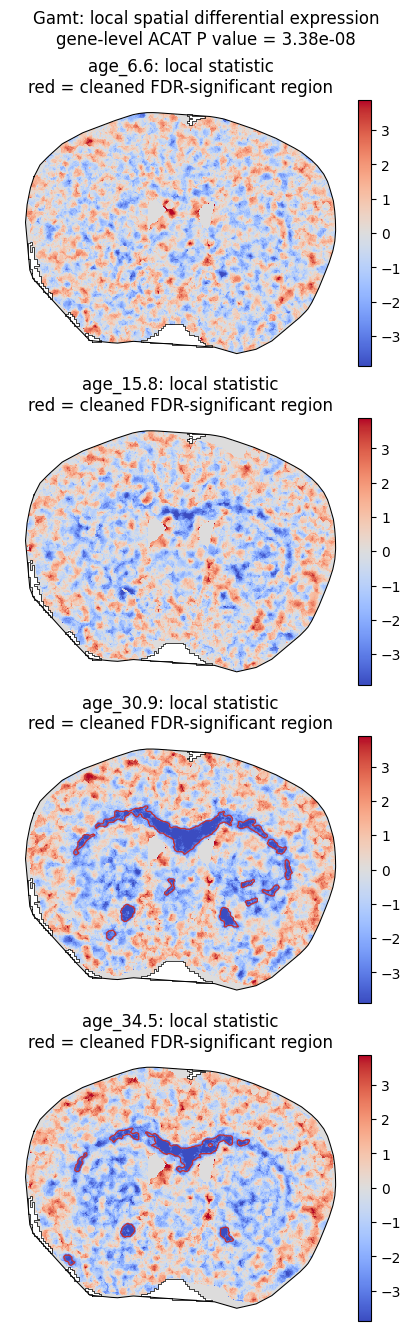

In [6]:
figure = plot_local_result(
    result,
    "Gamt",
    show_expression=False,
)